In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the dataset

df = pd.read_csv(
    r"C:\Users\91958\Desktop\Machine Learning\datasets\Position_Salaries.csv"
)

# Display the first five rows

df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
# Displaying dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 368.0+ bytes


In [4]:
# Statistical summary of numerical columns

df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [5]:
# Checking for missing values

df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [6]:
# Displaying dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10
Columns : 3


In [7]:
# Removing the Position column (if it exists)

if "Position" in df.columns:
    df = df.drop("Position", axis=1)

# Selecting independent and dependent variables

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Features:


,Level
0,1
1,2
2,3
3,4
4,5



Target:


0     45000
1     50000
2     60000
3     80000
4    110000
Name: Salary, dtype: int64


Features Shape: (10, 1)
Target Shape: (10,)


In [8]:
# Splitting the dataset into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (8, 1)
Testing Features : (2, 1)
Training Labels : (8,)
Testing Labels : (2,)


In [9]:
# Training the Decision Tree Regression model

model = DecisionTreeRegressor(
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree Regression model trained successfully!")

Decision Tree Regression model trained successfully!


In [10]:
# Predicting the test data

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[300000.  45000.]


In [11]:
# Predicting the test data

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[300000.  45000.]


In [12]:
from sklearn.metrics import mean_absolute_error

# Calculating Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 102500.00


In [13]:
from sklearn.metrics import mean_squared_error

# Calculating Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")

Mean Squared Error (MSE): 20012500000.00


In [14]:
from sklearn.metrics import root_mean_squared_error

# Calculating Root Mean Squared Error

rmse = root_mean_squared_error(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 141465.54


In [15]:
from sklearn.metrics import r2_score

# Calculating R² Score

r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

R² Score: 0.6047


In [16]:
# Predicting salary for a new position level

new_level = pd.DataFrame({
    "Level": [6.5]
})

predicted_salary = model.predict(new_level)

print(f"Predicted Salary for Level 6.5: ₹{predicted_salary[0]:,.2f}")

Predicted Salary for Level 6.5: ₹150,000.00


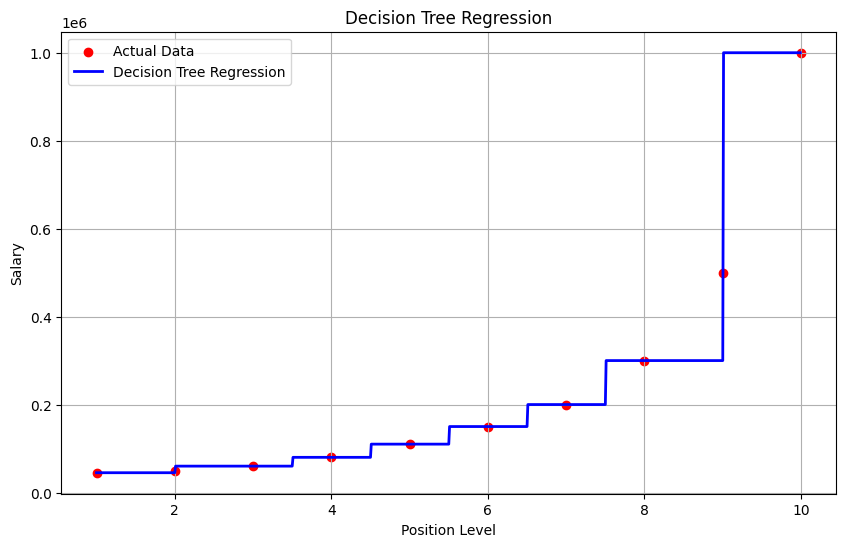

In [17]:
# Visualizing the Decision Tree Regression results

X_grid = np.arange(
    min(X.values),
    max(X.values),
    0.01
)

X_grid = X_grid.reshape((len(X_grid), 1))

plt.figure(figsize=(10,6))

plt.scatter(
    X,
    y,
    color="red",
    label="Actual Data"
)

plt.plot(
    X_grid,
    model.predict(X_grid),
    color="blue",
    linewidth=2,
    label="Decision Tree Regression"
)

plt.title("Decision Tree Regression")
plt.xlabel("Position Level")
plt.ylabel("Salary")

plt.legend()
plt.grid(True)

plt.show()

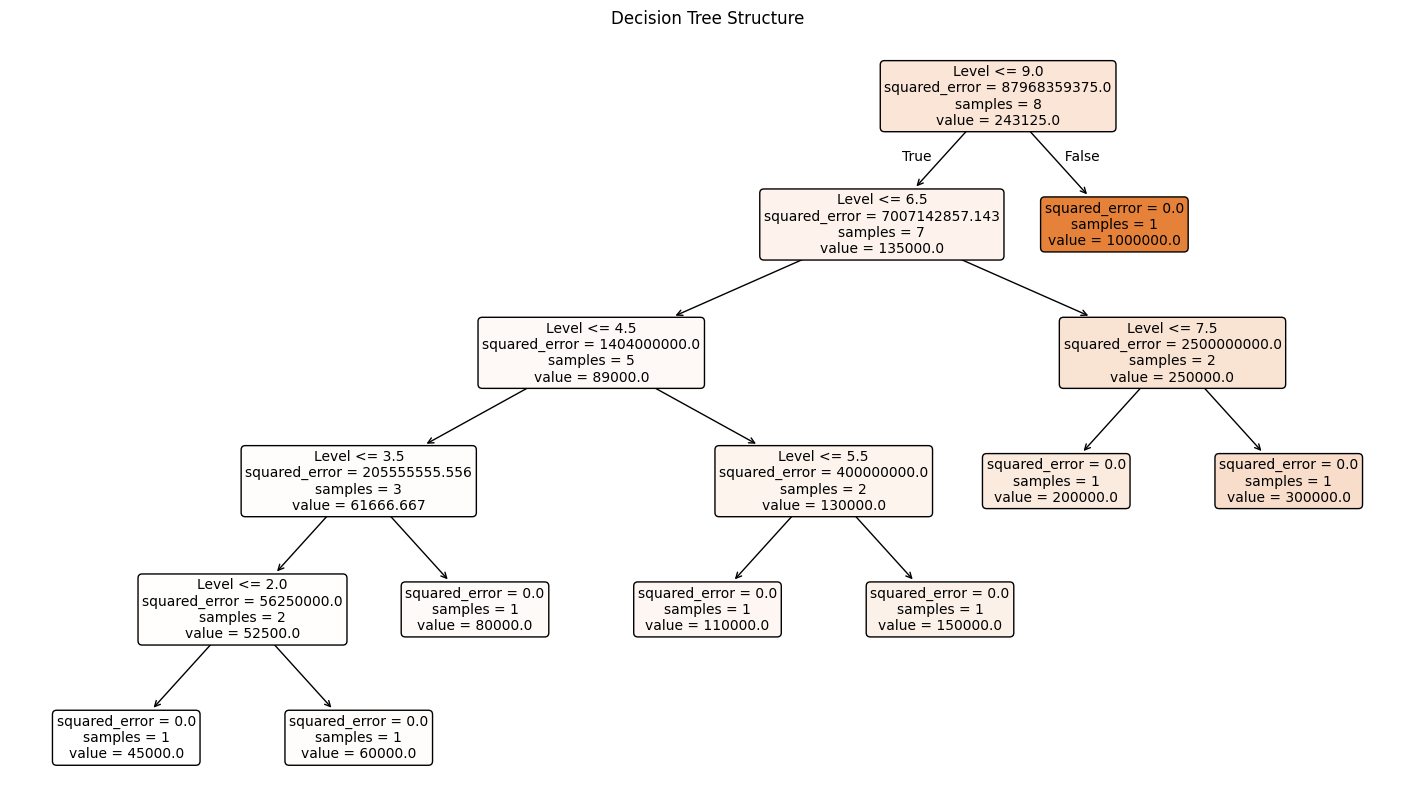

In [18]:
from sklearn.tree import plot_tree

# Visualizing the Decision Tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Structure")

plt.show()

In [19]:
# Displaying Decision Tree Hyperparameters

parameters = pd.DataFrame({
    "Hyperparameter": model.get_params().keys(),
    "Value": model.get_params().values()
})

display(parameters)

,Hyperparameter,Value
0,ccp_alpha,0.0
1,criterion,squared_error
2,max_depth,None
3,max_features,None
4,max_leaf_nodes,None
5,min_impurity_decrease,0.0
6,min_samples_leaf,1
7,min_samples_split,2
8,min_weight_fraction_leaf,0.0
9,monotonic_cst,None


,Feature,Importance
0,Level,1.0


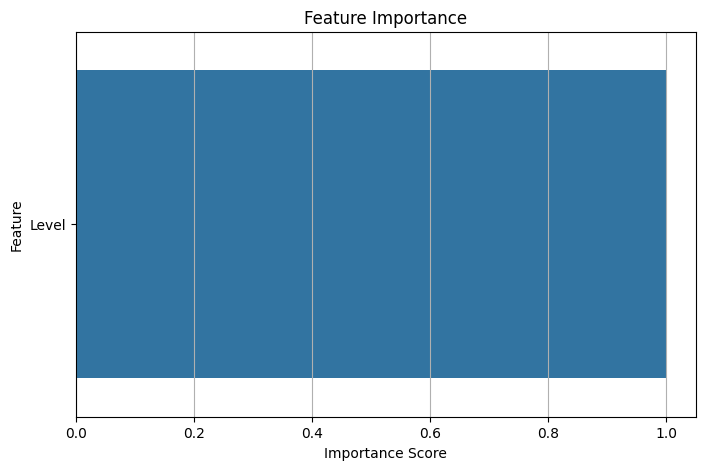

In [20]:
# Displaying Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.grid(axis="x")

plt.show()